3.2 Task - 1: Implementation of MCP Neurons:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


MCP Neuron for AND Function

Logic:
Output = 1 only if both inputs are 1

So threshold T = 2

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND operation using MCP Neuron.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise aggregation and thresholding
    for i in range(len(X1)):
        total = X1[i] + X2[i]  # aggregation

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"AND Output: {result}")

AND Output: [0, 0, 0, 1]


MCP Neuron for OR Function

Logic:

Output = 1 if at least one input is 1

So threshold T = 1

In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR operation using MCP Neuron.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    # Element-wise aggregation and thresholding
    for i in range(len(X1)):
        total = X1[i] + X2[i]  # aggregation

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR Output: {result_or}")

OR Output: [0, 1, 1, 1]


Key Concept (MCP Neuron)
Aggregation:

𝑆
=𝑋
1
+
𝑋
2

S=X1+X2

Activation (Step Function):

If
𝑆
≥
𝑇
S≥T → output = 1

Else → output = 0

3.2.1 Answer the Following Question:
• You can use Text cell of your notebook to answer the question.
• Question - 1: List out all the limitations of MCP - Neurons.

a. Can not solve XOR

b. It only support binary inputs i.e 0 and 1 and not continuous values

c.There is no training mechanism which means it cannot adapt from data uinlike the modern neural network

d.It cannot handle the model complex decision boundaries

e.Limited read-world applicability.

• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

Logic for MCP Neuron

x1     x2    XOR Output

0      0        0

0      1        1

1      0        1

1      1        0

A single MCP neuron cannot solve XOR, but we can simulate XOR using multiple MCP neurons (layered logic or rule-based approach).

In [ ]:
#If-Else Logic for XOR
def MCP_XOR(X1, X2):
    result = []

    for i in range(len(X1)):
        if (X1[i] == 0 and X2[i] == 1) or (X1[i] == 1 and X2[i] == 0):
            result.append(1)
        else:
            result.append(0)

    return result

4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/"))

['Colab Notebooks', 'niyatikayastha_workshop1.ipynb', 'Workshop-4.pdf', 'Workshop-4.gdoc', 'SumedhaMali_week5.ipynb', 'Python Assignment.docx', 'SumedhaMali_week1', 'SumedhaMali_week3 (1).ipynb', 'SumedhaMali_week4', 'Python_SumedhaMali', 'SumedhaMali_week6.ipynb', 'SumedhaMali_week7', 'Untitled document (3).gdoc', 'Assets and Tutorials Used Template.docx', 'Untitled document (2).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'final_submission', 'Assets and tutorials log_2408480.docx', 'Prajanya_Shrestha_2408648.zip', 'Worksheet - 0 - Essentials of Python for ML..pdf', 'Worksheet - 0 - Essentials of Python for ML..gdoc', 'SumedhaMaliweek1.ipynb', 'SumedhaMali_week0_2408480.ipynb', 'SumedhaMaliweek1 .ipynb', 'bank .csv', 'Worksheet2', 'SumedhaMali_week2.ipynb', 'SumedhaMali_week3.ipynb', 'worksheet4', 'SumedhaMali_AssignmentAI_230335', 'Copy of Engineering Project Proposal by Slidesgo.gslides', 'Tut - 07 - Solutions.pdf', '5CS021 - Assessment (1).pdf', '5CS021 - Assessme

In [ ]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("//content/drive/MyDrive/AI and ML week 3 worksheet3/mnist_0_and_1.csv")
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Answer the Following Question:
1. Question - 1: What does the shape of X represent?
ans: it represents the dimension of features.
2. Question - 2: What does the shape of Y represent?
ans: it represents the dimension of labeled.

Visualize the dataset

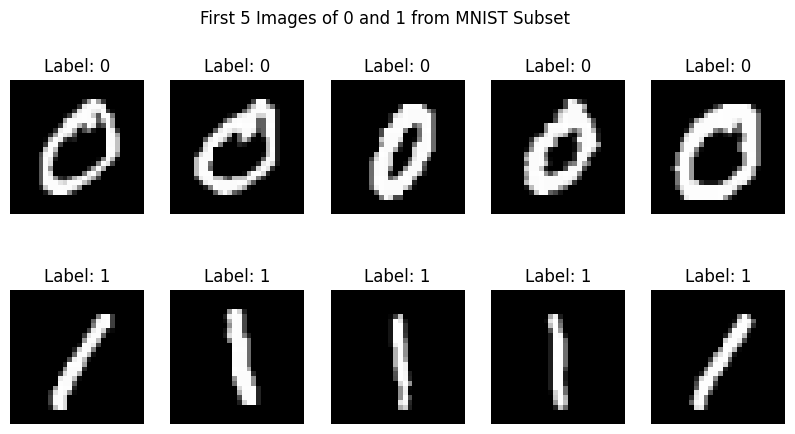

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]
images_1 = X[y == 1]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have enough data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

Initialize Weights and Bias:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question - 3: What does the weights array represent in this context?

Ans:The weights array represents the importance of each pixel (feature) in making a prediction.

Since each image has 784 pixels (28 × 28), we have 784 weights. Hence, each weight corresponds to one pixel. It determines how much that pixel contributes to the final decision. In simple terms, each pixel value is multiplied by its corresponding weight. Then all values are summed (along with bias) to make a prediction

Mathematically:

𝑧=𝑤
1
𝑥
1
+
𝑤
2
𝑥
2
+
⋯
+
𝑤
784
𝑥
784
+
𝑏

So, Larger weight means pixel is more important and smaller/zero weight means pixel has little or no effect.

2. Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Ans:It provides a simple starting point and it is easy to implement and understand. The model will learn and update weights during training. The zero initialization is fine for simple models (like perceptron).

The potential issues that could arise are
a. Slow learning at the beginning
b. All features start with equal importance
c. Symmetry problem (in multi-layer networks)
d. If all weights are the same, neurons learn the same thing. This prevents learning complex patterns


Implement a Decision Function or Activation Function:

Implementation Decision Function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """
    predictions = np.dot(X, weights) + bias

    # Step activation function
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

Implement the Perceptron Learning Algorithm:

Training the Perceptron:

In [ ]:
import numpy as np

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for epoch in range(epochs):
        for i in range(len(X)):

            # Linear combination
            output = np.dot(X[i], weights) + bias

            # Step function
            y_pred = 1 if output >= 0 else 0

            # Update if prediction is wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

    # Calculate final accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy

Answer the Following Question:
1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans:This line computes the weighted sum of inputs, which is the prediction score of the model. X[i] is the input features (e.g., [x₁, x₂, x₃]) and weights is the importance of each feature. np.dot(X[i], weights) multiplies each input with its weight and sums them whereas bias shifts the result. This is the core prediction step. It decides whether the model predicts class 0 or 1.
It calculates:

output
=
𝑥
1
𝑤
1
+
𝑥
2
𝑤
2
+
𝑥
3
𝑤
3
+
𝑏

2. Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?

Ans: The model learns from the mistake by updating weights and bias. If prediction is too low then weights increase while if prediction is too high then weights decrease. This gradually improves the model.

3. Question - 7:Why is the final accuracy important, and what do you expect it to be?

Ans: Final accuracy tells us how well the model performs overall. The formula for the accuracy is : Accuracy = Correct Predictions / total prediction. It is important as it measures model performance, shows if learning was successful and helps compare models.
The accuracy being close to 100% is really gopd but in the context of real-world model and data complexity close to 80% to 995% is considered good.

Putting it all Together:

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


Visualizing the Misclassified Image:

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()

else:
    print("All images were correctly classified!")


Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question - 8:What does misclassified idx store, and how is it used in this code?

Ans: It stores indices (positions) of all wrongly predicted data points.

The code : for ax, idx in zip(axes.flat, misclassified_idx[:10]):
It selects first 10 wrong predictions and displays those images.

X[idx].reshape(28, 28): It shows the actual misclassified image.

It helps you see where model is making mistakes.

2. Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Ans:If the output is ”All images were
correctly classified!”, it means that model predicted every data point correctly. In other words, it means that model performance is perfect (on this dataset).

This can mean two thing:
Model is very accurate or model may be overfitting and it memorized training data instead of learning patterns.


Task 3: Perceptron Algorithm for 3 vs 5 Classification.

To - Do:
1. Implement each Step as we implemented above.
2. Visualize the final misclassified images and Provide your conclusion.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/AI and ML week 3 worksheet3/mnist_3_and_5.csv")

#Seperate feature x and label y
X = data.drop(columns=["label"]).values
y = data["label"].values

#Normalize pixel values
X = X / 255.0

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)



Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


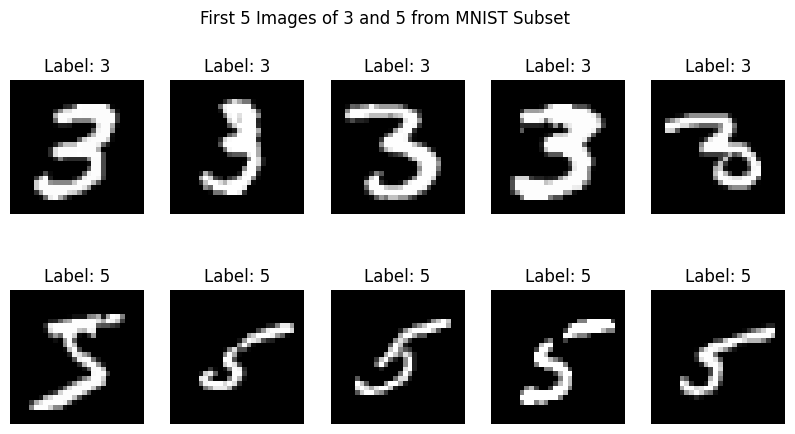

In [ ]:
# Step 2: Visualize first few images
images_3 = X[y == 3]
images_5 = X[y == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.show()

In [ ]:
import numpy as np

# --- Step 3: Initialize ---
weights = np.zeros(X.shape[1])  # 784 weights
bias = 0
learning_rate = 0.1
epochs = 100

# --- Step 4: Decision function ---
def decision_function(X, weights, bias):
    # Compute the weighted sum for all samples
    predictions = np.dot(X, weights) + bias
    # If score >= 0, predict 1 (Digit 5), else 0 (Digit 3)
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# --- Step 5: Train Perceptron Function ---
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    # Pre-process: Map actual labels (3, 5) to binary (0, 1)
    y_binary = np.where(y == 5, 1, 0)
    n_samples = len(X)

    for epoch in range(epochs):
        errors_in_epoch = 0  # Initialize error counter at the start of each epoch

        for i in range(n_samples):
            # Compute weighted sum (z)
            linear_output = np.dot(X[i], weights) + bias

            # Prediction (y_hat) - using binary 0 and 1
            y_pred = 1 if linear_output >= 0 else 0
  # Update weights if misclassified
            if y_pred != y_binary[i]:
                # Error is (Target - Prediction)
                error = y_binary[i] - y_pred

                # Update Rule: W = W + eta * error * X
                weights += learning_rate * error * X[i]
                bias += learning_rate * error

                errors_in_epoch += 1

        # Calculate accuracy for the current epoch
        accuracy = 1 - (errors_in_epoch / n_samples)

        # Convergence check: If no errors occurred in a full pass, stop early
        if errors_in_epoch == 0:
            print(f"Converged early at epoch {epoch}")
            break

    return weights, bias, accuracy


In [ ]:
# After training, accuracy will reflect the performance of the final epoch
weights, bias, final_accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"The Final Training Accuracy is: {final_accuracy:.4f}")

The Final Training Accuracy is: 0.9836


Final Accuracy: 0.9916


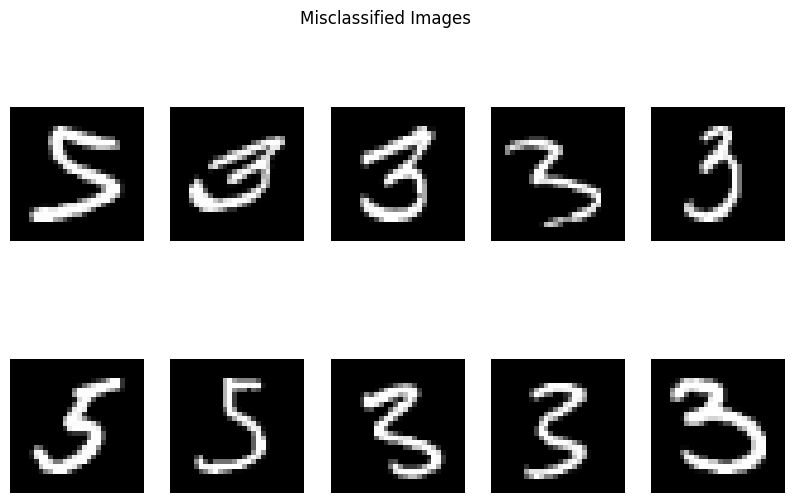

In [ ]:
# Getting raw scores (z = W.X + b)
predictions_raw = np.dot(X, weights) + bias

# Converting raw scores to binary predictions (0 or 1)
y_pred_binary = np.where(predictions_raw >= 0, 1, 0)

# Creating a binary version of the ground truth for comparison
# We assume 5 is the 'positive' class (1) and 3 is 'negative' (0)
y_binary = np.where(y == 5, 1, 0)

# Calculating final accuracy
final_accuracy = np.mean(y_pred_binary == y_binary)
print(f"Final Accuracy: {final_accuracy:.4f}")

#Step 7: Visualize Misclassified Images

# Find the indices where the binary prediction doesn't match the binary truth
misclassified_idx = np.where(y_pred_binary != y_binary)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    # Map the binary predictions back to human-readable digits (3 and 5)
    # If prediction was 1, it's a 5. If it was 0, it's a 3.
    y_pred_digits = np.where(y_pred_binary == 1, 5, 3)
    #Show 10 misclasiified images
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        # Show the image (reshape 784 back to 28x28)
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly identified.")

Conclusion

The perceptron successfully classified digits 3 and 5 with decent accuracy, but some errors occurred because the two digits can look visually similar. As a linear model, the perceptron has difficulty handling complex patterns and overlapping features. Most misclassifications happen when the images have shapes that resemble both digits.